# BTUMQA-225K EDA Notebook

This notebook performs exploratory data analysis on the `BTUMQA-225K` uncertainty-first benchmark before Phase 3B preprocessing.

Main goals:
- verify release integrity and schema
- inspect benchmark balance across families, styles, difficulty, and ambiguity
- audit answer skew and potentially weak families
- summarize patient and slice coverage
- inspect uncertainty and reliability distributions for future modeling decisions


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


In [2]:
from google.colab import drive
drive.mount("/content/drive")

# Change only this project path if needed.
PROJECT_DRIVE_DIR = Path(
    "/content/drive/MyDrive/AUGR-VQA"
)

DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
LOGS_DIR = DATASET_DIR / "logs"

DATA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"
TRAIN_PATH = DATASET_DIR / "btumqa_225k_train.csv"
VAL_PATH = DATASET_DIR / "btumqa_225k_val.csv"
TEST_PATH = DATASET_DIR / "btumqa_225k_test.csv"
REPORT_PATH = LOGS_DIR / "dataset_generation_report.json"
FAMILY_PATH = LOGS_DIR / "question_family_inventory.json"
RULE_PATH = LOGS_DIR / "decision_rule_inventory.json"
THRESHOLD_PATH = LOGS_DIR / "threshold_inventory.json"

for path in [DATA_PATH, TRAIN_PATH, VAL_PATH, TEST_PATH, REPORT_PATH, FAMILY_PATH, RULE_PATH, THRESHOLD_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

DATASET_DIR

Mounted at /content/drive


PosixPath('/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k')

In [3]:
df = pd.read_csv(DATA_PATH)
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

with REPORT_PATH.open("r", encoding="utf-8") as handle:
    report = json.load(handle)

with FAMILY_PATH.open("r", encoding="utf-8") as handle:
    family_inventory = json.load(handle)

with RULE_PATH.open("r", encoding="utf-8") as handle:
    rule_inventory = json.load(handle)

with THRESHOLD_PATH.open("r", encoding="utf-8") as handle:
    threshold_inventory = json.load(handle)

print(df.shape)
print(train_df.shape, val_df.shape, test_df.shape)


(225000, 47)
(157500, 47) (33750, 47) (33750, 47)


## Release Integrity

In [4]:
integrity_summary = {
    "total_rows": len(df),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "unique_qa_ids": df["qa_id"].nunique(),
    "duplicate_qa_ids": int(len(df) - df["qa_id"].nunique()),
    "unique_patients": df["patient_id"].nunique(),
    "unique_slices": df["unique_id"].nunique(),
    "patient_overlap_train_val": int(len(set(train_df["patient_id"]).intersection(set(val_df["patient_id"])))),
    "patient_overlap_train_test": int(len(set(train_df["patient_id"]).intersection(set(test_df["patient_id"])))),
    "patient_overlap_val_test": int(len(set(val_df["patient_id"]).intersection(set(test_df["patient_id"])))),
}
pd.Series(integrity_summary)


,0
total_rows,225000
train_rows,157500
val_rows,33750
test_rows,33750
unique_qa_ids,225000
duplicate_qa_ids,0
unique_patients,1251
unique_slices,72025
patient_overlap_train_val,0
patient_overlap_train_test,0


## Schema and Missingness

In [5]:
schema_preview = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_count": [int(df[col].isna().sum()) for col in df.columns],
    "missing_pct": [float(df[col].isna().mean()) * 100.0 for col in df.columns],
})
schema_preview.head(60)


,column,dtype,missing_count,missing_pct
0,qa_id,object,0,0.000000
1,split,object,0,0.000000
2,patient_id,int64,0,0.000000
3,slice_id,int64,0,0.000000
4,unique_id,object,0,0.000000
5,image_id,int64,0,0.000000
6,question,object,0,0.000000
7,answer,object,0,0.000000
8,answer_type,object,0,0.000000
9,question_family,object,0,0.000000


In [6]:
schema_preview.sort_values(["missing_pct", "column"], ascending=[False, True]).head(25)


,column,dtype,missing_count,missing_pct
17,region_target_secondary,object,39196,17.420444
15,ambiguity_flag,object,0,0.000000
7,answer,object,0,0.000000
8,answer_type,object,0,0.000000
21,candidate_keep_reason,object,0,0.000000
28,context_area_pixels,int64,0,0.000000
34,context_uncertainty,float64,0,0.000000
40,context_weight,float64,0,0.000000
12,dataset_branch,object,0,0.000000
19,decision_rule_id,object,0,0.000000


## Core Benchmark Distributions

In [7]:
distribution_tables = {
    "split": df["split"].value_counts().sort_index(),
    "question_family": df["question_family"].value_counts(),
    "question_style": df["question_style"].value_counts(),
    "difficulty_level": df["difficulty_level"].value_counts(),
    "ambiguity_flag": df["ambiguity_flag"].value_counts(),
    "candidate_keep_reason": df["candidate_keep_reason"].value_counts(),
    "label_provenance": df["label_provenance"].value_counts(),
}

for name, series in distribution_tables.items():
    print(f"\n=== {name.upper()} ===")
    display(series.to_frame("count").assign(pct=lambda x: (x["count"] / len(df) * 100).round(3)))



=== SPLIT ===


,count,pct
split,,
test,33750,15.0
train,157500,70.0
val,33750,15.0



=== QUESTION_FAMILY ===


,count,pct
question_family,,
ambiguous_subregion_pair,22501,10.0
dominant_region_under_uncertainty,22500,10.0
uncertainty_consistency_check,22499,10.0
safe_region_for_reasoning,18000,8.0
uncertainty_gap_bucket,18000,8.0
more_uncertain_region,18000,8.0
more_reliable_region,18000,8.0
reliability_gap_bucket,18000,8.0
highest_risk_region,16875,7.5



=== QUESTION_STYLE ===


...

,count,pct
ambiguity_flag,,
no,147859,65.715
yes,77141,34.285



=== CANDIDATE_KEEP_REASON ===


,count,pct
candidate_keep_reason,,
balanced_family_sampling,119515,53.118
ambiguity_priority,89995,39.998
patient_diversity_fill,15490,6.884



=== LABEL_PROVENANCE ===


,count,pct
label_provenance,,
phase1_pseudo_mask+phase2b_uncertainty,101250,45.0
phase2b_uncertainty,36000,16.0
phase2c_weight,36000,16.0
phase2a_area+phase2b_uncertainty,33750,15.0
phase2a_area+phase2c_weight,18000,8.0


/tmp/ipykernel_2903/82019931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
/tmp/ipykernel_2903/82019931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
/tmp/ipykernel_2903/82019931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
/tmp/ipykernel_2903/82019931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

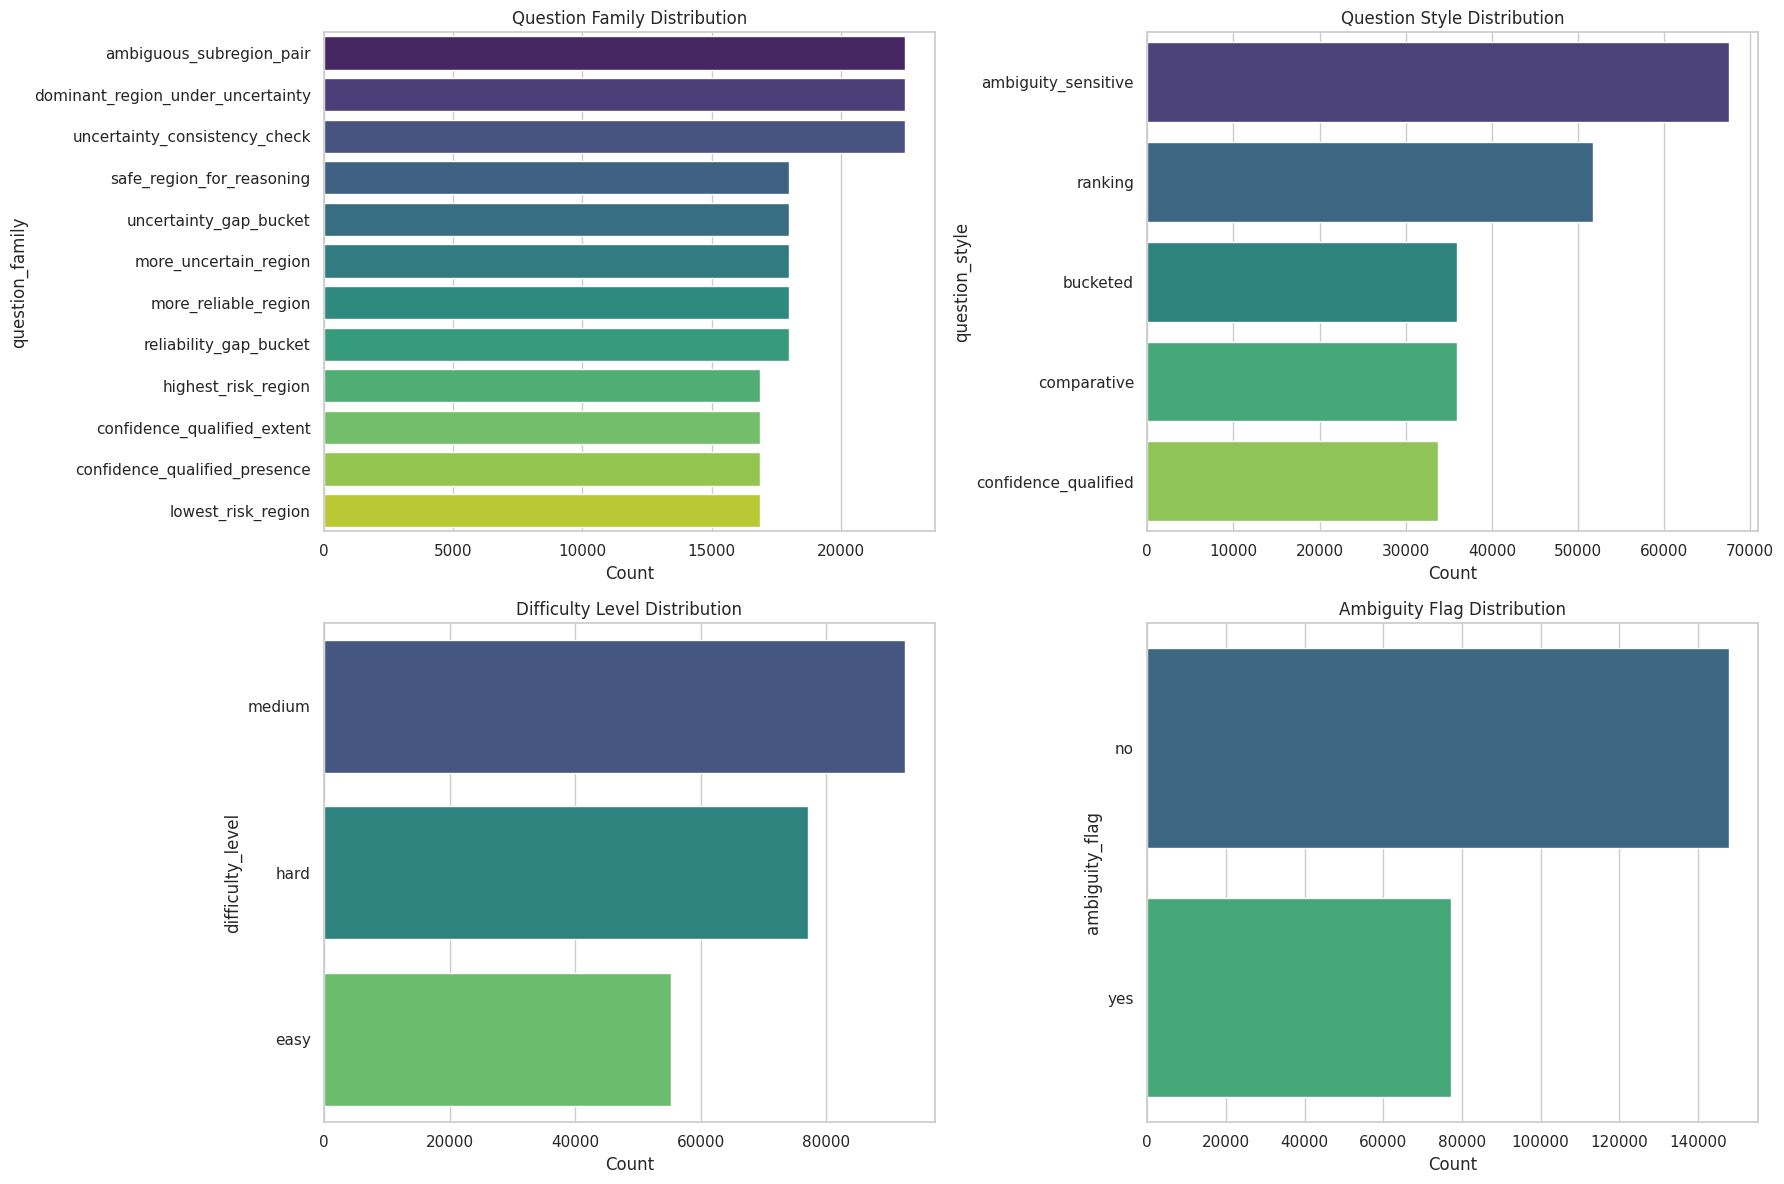

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plot_specs = [
    ("question_family", axes[0, 0], "Question Family Distribution"),
    ("question_style", axes[0, 1], "Question Style Distribution"),
    ("difficulty_level", axes[1, 0], "Difficulty Level Distribution"),
    ("ambiguity_flag", axes[1, 1], "Ambiguity Flag Distribution"),
]

for column, ax, title in plot_specs:
    counts = df[column].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()


## Family-by-Split and Family-by-Difficulty

In [9]:
family_split = pd.crosstab(df["question_family"], df["split"])
family_difficulty = pd.crosstab(df["question_family"], df["difficulty_level"])
family_ambiguity = pd.crosstab(df["question_family"], df["ambiguity_flag"])

display(family_split)
display(family_difficulty)
display(family_ambiguity)


split,test,train,val
question_family,,,
ambiguous_subregion_pair,3374,15751,3376
confidence_qualified_extent,2532,11812,2531
confidence_qualified_presence,2532,11812,2531
dominant_region_under_uncertainty,3374,15751,3375
highest_risk_region,2532,11812,2531
lowest_risk_region,2532,11812,2531
more_reliable_region,2700,12600,2700
more_uncertain_region,2700,12600,2700
reliability_gap_bucket,2700,12600,2700


difficulty_level,easy,hard,medium
question_family,,,
ambiguous_subregion_pair,9110,4533,8858
confidence_qualified_extent,2410,7232,7233
confidence_qualified_presence,5623,5622,5630
dominant_region_under_uncertainty,11947,2825,7728
highest_risk_region,5642,5282,5951
lowest_risk_region,6308,4858,5709
more_reliable_region,3692,7307,7001
more_uncertain_region,3697,7294,7009
reliability_gap_bucket,1319,11465,5216


ambiguity_flag,no,yes
question_family,,
ambiguous_subregion_pair,17968,4533
confidence_qualified_extent,9642,7233
confidence_qualified_presence,11245,5630
dominant_region_under_uncertainty,19675,2825
highest_risk_region,11593,5282
lowest_risk_region,12017,4858
more_reliable_region,10693,7307
more_uncertain_region,10706,7294
reliability_gap_bucket,6535,11465


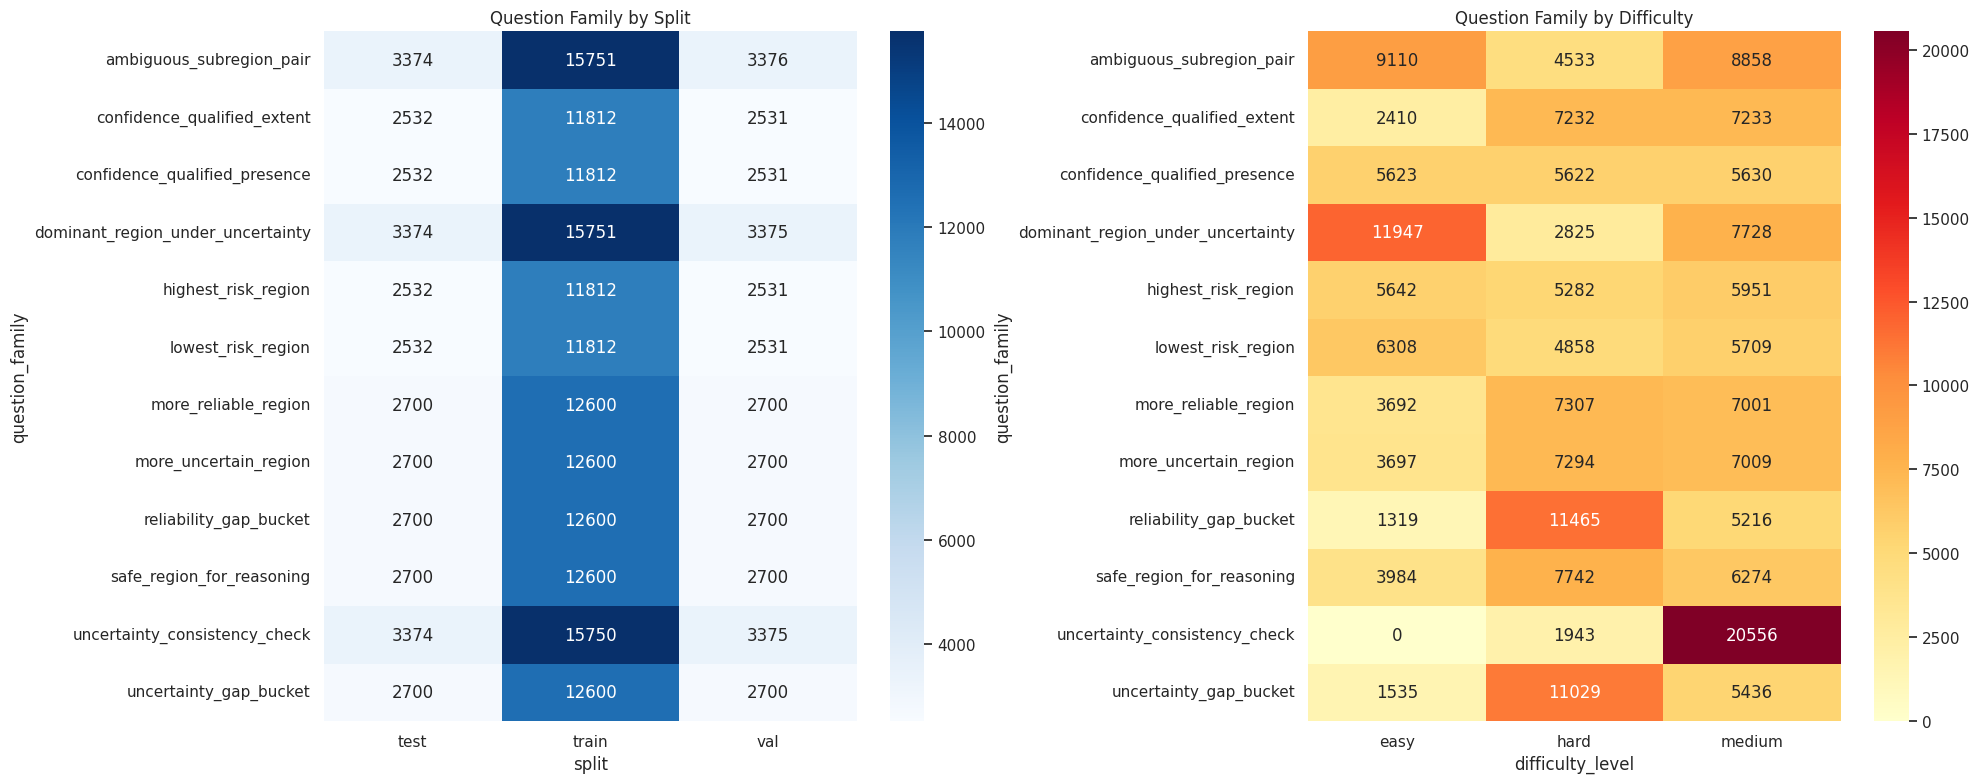

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(family_split, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Question Family by Split")
sns.heatmap(family_difficulty, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Question Family by Difficulty")
plt.tight_layout()
plt.show()


## Answer Distribution Audit

In [11]:
answer_by_family = (
    df.groupby(["question_family", "answer"]).size().rename("count").reset_index()
)
answer_by_family["family_total"] = answer_by_family.groupby("question_family")["count"].transform("sum")
answer_by_family["pct_within_family"] = (answer_by_family["count"] / answer_by_family["family_total"] * 100).round(3)
answer_by_family.sort_values(["question_family", "count"], ascending=[True, False]).head(80)


,question_family,answer,count,family_total,pct_within_family
1,ambiguous_subregion_pair,distinct,17968,22501,79.854
0,ambiguous_subregion_pair,ambiguous,4533,22501,20.146
2,confidence_qualified_extent,large_confident,2412,16875,14.293
3,confidence_qualified_extent,large_uncertain,2412,16875,14.293
4,confidence_qualified_extent,moderate_confident,2412,16875,14.293
5,confidence_qualified_extent,moderate_uncertain,2411,16875,14.287
6,confidence_qualified_extent,none,2410,16875,14.281
7,confidence_qualified_extent,small_confident,2409,16875,14.276
8,confidence_qualified_extent,small_uncertain,2409,16875,14.276
9,confidence_qualified_presence,confident_present,5630,16875,33.363


In [12]:
dominant_answer_audit = (
    answer_by_family.sort_values(["question_family", "count"], ascending=[True, False])
    .groupby("question_family")
    .head(1)
    [["question_family", "answer", "count", "pct_within_family"]]
    .sort_values("pct_within_family", ascending=False)
)
dominant_answer_audit


,question_family,answer,count,pct_within_family
43,uncertainty_consistency_check,consistent,20556,91.364
1,ambiguous_subregion_pair,distinct,17968,79.854
36,reliability_gap_bucket,close_gap,11465,63.694
45,uncertainty_gap_bucket,close_gap,11029,61.272
42,safe_region_for_reasoning,tumor,8557,47.539
12,dominant_region_under_uncertainty,edema,10459,46.484
9,confidence_qualified_presence,confident_present,5630,33.363
21,lowest_risk_region,context,5049,29.920
19,highest_risk_region,ncr_net,4470,26.489
30,more_reliable_region,tumor,3802,21.122


## Coverage Audit

In [13]:
coverage_summary = pd.DataFrame({
    "rows": df.groupby("split").size(),
    "unique_patients": df.groupby("split")["patient_id"].nunique(),
    "unique_slices": df.groupby("split")["unique_id"].nunique(),
    "rows_per_patient": (df.groupby("split").size() / df.groupby("split")["patient_id"].nunique()).round(3),
    "rows_per_slice": (df.groupby("split").size() / df.groupby("split")["unique_id"].nunique()).round(3),
})
coverage_summary


,rows,unique_patients,unique_slices,rows_per_patient,rows_per_slice
split,,,,,
test,33750,187,10929,180.481,3.088
train,157500,876,50481,179.795,3.120
val,33750,188,10615,179.521,3.179


In [14]:
patient_load = df.groupby("patient_id").size().rename("rows_per_patient")
slice_load = df.groupby("unique_id").size().rename("rows_per_slice")

print(patient_load.describe())
print()
print(slice_load.describe())


count    1251.000000
mean      179.856115
std        51.652486
min        47.000000
25%       142.000000
50%       188.000000
75%       234.000000
max       235.000000
Name: rows_per_patient, dtype: float64

count    72025.000000
mean         3.123915
std          1.794211
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         13.000000
Name: rows_per_slice, dtype: float64


## Numeric Signal Audit

In [15]:
uncertainty_cols = [f"{region}_uncertainty" for region in ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]]
weight_cols = [f"{region}_weight" for region in ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]]
area_cols = [f"{region}_area_pixels" for region in ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]]

display(df[uncertainty_cols].describe().T)
display(df[weight_cols].describe().T)
display(df[area_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
edema_uncertainty,225000.0,0.020325,0.026259,0.000000e+00,0.006446,0.012596,0.023884,0.471253
ncr_net_uncertainty,225000.0,0.029880,0.050127,0.000000e+00,0.003861,0.012212,0.032936,0.585407
enhancing_uncertainty,225000.0,0.026366,0.060996,0.000000e+00,0.002598,0.006058,0.016823,0.807623
tumor_uncertainty,225000.0,0.020126,0.031415,0.000000e+00,0.005902,0.010573,0.020557,0.500620
context_uncertainty,225000.0,0.007945,0.011931,0.000000e+00,0.002742,0.004613,0.008344,0.233382
global_uncertainty,225000.0,0.003371,0.005628,4.000000e-08,0.001018,0.001785,0.003389,0.065018


,count,mean,std,min,25%,50%,75%,max
edema_weight,225000.0,0.979675,0.026259,0.528747,0.976116,0.987404,0.993554,1.0
ncr_net_weight,225000.0,0.970120,0.050127,0.414593,0.967064,0.987788,0.996139,1.0
enhancing_weight,225000.0,0.973634,0.060996,0.192377,0.983177,0.993942,0.997402,1.0
tumor_weight,225000.0,0.979874,0.031415,0.499380,0.979443,0.989427,0.994098,1.0
context_weight,225000.0,0.992055,0.011931,0.766618,0.991656,0.995387,0.997258,1.0
global_weight,225000.0,0.996629,0.005628,0.934982,0.996611,0.998215,0.998982,1.0


,count,mean,std,min,25%,50%,75%,max
edema_area_pixels,225000.0,962.457476,779.680397,0.0,386.0,801.0,1374.0,12816.0
ncr_net_area_pixels,225000.0,387.258262,572.639432,0.0,17.0,165.0,556.0,9226.0
enhancing_area_pixels,225000.0,408.850244,415.458668,0.0,32.0,312.0,655.0,3072.0
tumor_area_pixels,225000.0,1758.565982,1255.218581,0.0,806.0,1635.0,2529.0,15326.0
context_area_pixels,225000.0,1939.987853,849.793229,0.0,1448.0,1958.0,2441.0,8576.0
global_area_pixels,225000.0,14965.897862,5395.282973,90.0,12874.0,15532.0,17133.0,57600.0


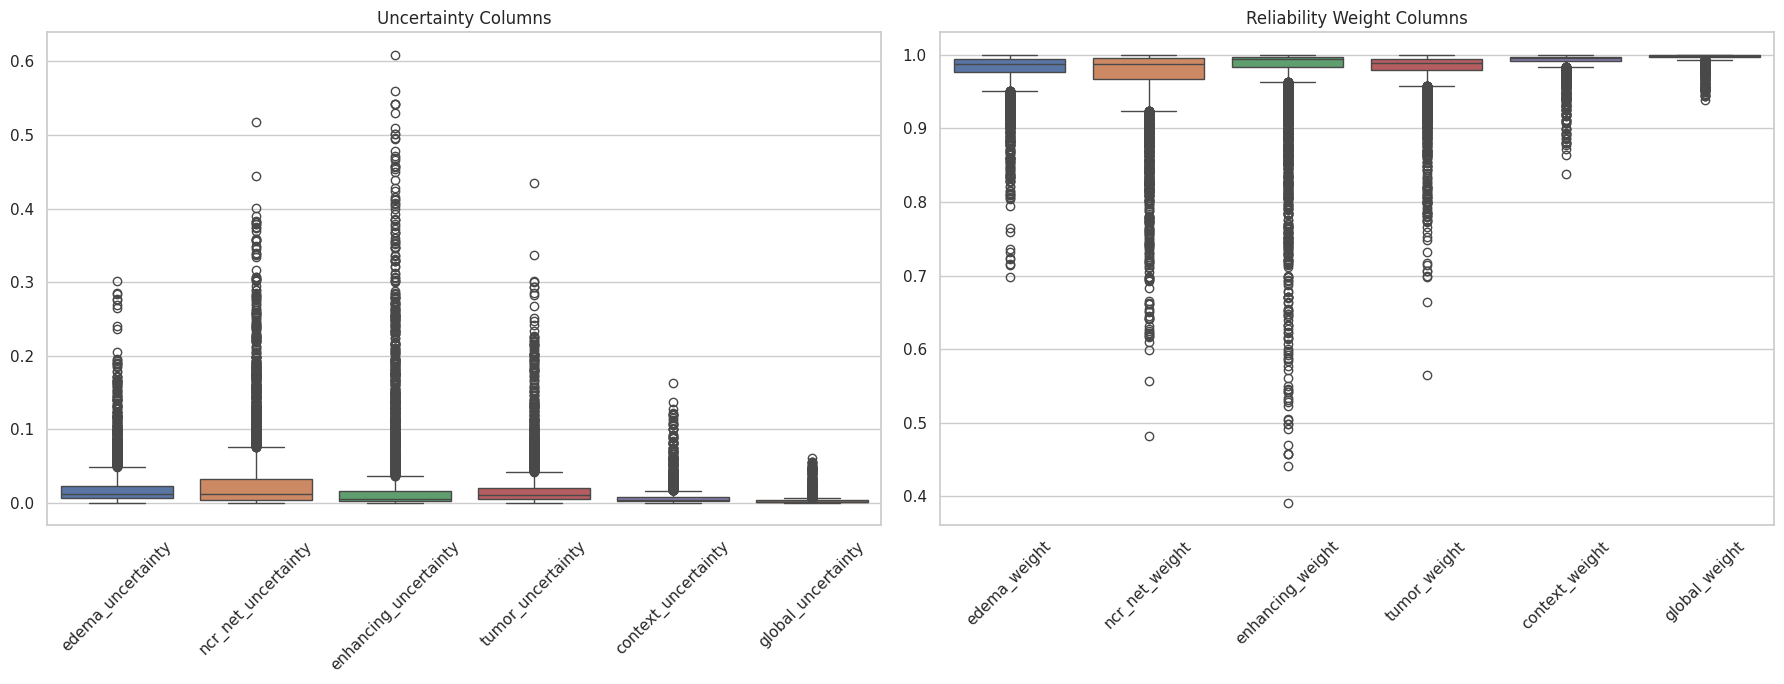

In [16]:
sample_numeric = df.sample(n=min(5000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.boxplot(data=sample_numeric[uncertainty_cols], ax=axes[0])
axes[0].set_title("Uncertainty Columns")
axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=sample_numeric[weight_cols], ax=axes[1])
axes[1].set_title("Reliability Weight Columns")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Family-Specific Risk Flags

In [17]:
risk_flags = []

for family, sub_df in df.groupby("question_family"):
    top_answer_pct = sub_df["answer"].value_counts(normalize=True).iloc[0] * 100.0
    ambiguity_yes_pct = (sub_df["ambiguity_flag"].eq("yes").mean() * 100.0)
    hard_pct = (sub_df["difficulty_level"].eq("hard").mean() * 100.0)
    risk_flags.append({
        "question_family": family,
        "top_answer_pct": round(top_answer_pct, 3),
        "ambiguity_yes_pct": round(ambiguity_yes_pct, 3),
        "hard_pct": round(hard_pct, 3),
        "needs_answer_balance_attention": top_answer_pct >= 75.0,
        "needs_hard_case_attention": hard_pct <= 15.0,
    })

risk_flags_df = pd.DataFrame(risk_flags).sort_values(["needs_answer_balance_attention", "top_answer_pct"], ascending=[False, False])
risk_flags_df


,question_family,top_answer_pct,ambiguity_yes_pct,hard_pct,needs_answer_balance_attention,needs_hard_case_attention
10,uncertainty_consistency_check,91.364,8.636,8.636,True,True
0,ambiguous_subregion_pair,79.854,20.146,20.146,True,False
8,reliability_gap_bucket,63.694,63.694,63.694,False,False
11,uncertainty_gap_bucket,61.272,61.272,61.272,False,False
9,safe_region_for_reasoning,47.539,43.011,43.011,False,False
3,dominant_region_under_uncertainty,46.484,12.556,12.556,False,True
2,confidence_qualified_presence,33.363,33.363,33.316,False,False
5,lowest_risk_region,29.920,28.788,28.788,False,False
4,highest_risk_region,26.489,31.301,31.301,False,False
6,more_reliable_region,21.122,40.594,40.594,False,False


## Benchmark Metadata Review

In [18]:
print("Family inventory keys:", family_inventory.keys())
print("Rule inventory keys:", rule_inventory.keys())
print("Threshold inventory keys:", threshold_inventory.keys())

display(pd.DataFrame(family_inventory["family_definitions"]).T)


Family inventory keys: dict_keys(['dataset_release_name', 'family_definitions', 'family_target_weights'])
Rule inventory keys: dict_keys(['dataset_release_name', 'rules'])
Threshold inventory keys: dict_keys(['dataset_release_name', 'threshold_policy', 'thresholds'])


,answer_space,description,difficulty_group,question_style
ambiguous_subregion_pair,"[ambiguous, distinct]",Determines whether a subregion pair is ambigui...,ambiguity_sensitive,ambiguity_sensitive
confidence_qualified_extent,"[none, small_confident, small_uncertain, moder...",Combines tumor extent with confidence qualific...,foundational,confidence_qualified
confidence_qualified_presence,"[confident_present, uncertain_present, not_pre...",Combines presence labeling with uncertainty qu...,foundational,confidence_qualified
dominant_region_under_uncertainty,"[edema, ncr_net, enhancing, none]",Selects the dominant tumor subregion after rel...,ambiguity_sensitive,ambiguity_sensitive
highest_risk_region,"[edema, ncr_net, enhancing, tumor, context, gl...",Ranking task based on uncertainty-weighted sup...,foundational,ranking
lowest_risk_region,"[edema, ncr_net, enhancing, tumor, context, gl...",Ranking task for the lowest evidence-risk region.,foundational,ranking
more_reliable_region,"[edema, ncr_net, enhancing, tumor, context, gl...",Pairwise comparison that asks which region is ...,comparative,comparative
more_uncertain_region,"[edema, ncr_net, enhancing, tumor, context, gl...",Pairwise comparison that asks which region has...,comparative,comparative
reliability_gap_bucket,"[close_gap, moderate_gap, wide_gap]",Buckets the reliability gap between two regions.,comparative,bucketed
safe_region_for_reasoning,"[edema, ncr_net, enhancing, tumor, context, gl...",Finds the safest region for reasoning based on...,comparative,ranking


## EDA Conclusions Template

Use this section after running the notebook to write down the main findings before Phase 3B preprocessing.

Recommended questions to answer:
- Which families are strongest and weakest in balance quality?
- Which families are too easy or too one-sided?
- Is ambiguity coverage sufficient for UGTM-sensitive experiments?
- Should any family be reweighted or regenerated before preprocessing?
- Are there any columns that should be excluded, merged, or specially normalized in Phase 3B?
